<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/Crosmatch_lsst_ztf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors

In [2]:
%%capture
!pip install alerce pyvo

In [6]:
from alerce.core import Alerce
import pyvo as vo

from astropy.timeseries import LombScargle
from astropy.coordinates import SkyCoord
import astropy.units as u

alerce_client = Alerce()

In [9]:
df = alerce_client.query_objects(
    survey="ztf",
    #classifier="lc_classifier_BHRF_forced_phot",
    classifier="lc_classifier",
    class_name="SNIa",
    probability=0.50,
    order_by="probability",
    order_mode="DESC",
    page_size=2000,
    format="pandas"
)
df.shape, df.oid.nunique(), df.columns, df.head()

((2000, 23),
 1994,
 Index(['oid', 'ndethist', 'ncovhist', 'mjdstarthist', 'mjdendhist',
        'corrected', 'stellar', 'ndet', 'g_r_max', 'g_r_max_corr', 'g_r_mean',
        'g_r_mean_corr', 'firstmjd', 'lastmjd', 'deltajd', 'meanra', 'meandec',
        'sigmara', 'sigmadec', 'class', 'classifier', 'probability',
        'step_id_corr'],
       dtype='object'),
             oid ndethist  ncovhist  mjdstarthist    mjdendhist  corrected  \
 0  ZTF20acobvxk      102       502  59149.448125  59204.198831      False   
 1  ZTF22aalpfln       59      2921  59724.250000  59766.250000      False   
 2  ZTF21abuyhau       53      2702  59448.184097  59478.194873      False   
 3  ZTF21abywdxt       44      1171  59464.267917  59502.204410      False   
 4  ZTF22abqdmwt       28       699  59877.250000  59932.250000      False   
 
    stellar  ndet   g_r_max  g_r_max_corr  ...       lastmjd    deltajd  \
 0    False    37 -0.185314      0.588599  ...  59204.198831  54.750706   
 1    False   

In [10]:
columns = ['oid', 'g_r_max', 'meanra', 'meandec', 'class', 'probability']
df = df[columns] if len(columns) > 0 else df
df.shape, df.oid.nunique(), df.columns, df.head()

((2000, 6),
 1994,
 Index(['oid', 'g_r_max', 'meanra', 'meandec', 'class', 'probability'], dtype='object'),
             oid   g_r_max      meanra    meandec class  probability
 0  ZTF20acobvxk -0.185314   37.673533 -14.569121  SNIa     0.722000
 1  ZTF22aalpfln -0.179750  224.503742  49.953109  SNIa     0.722000
 2  ZTF21abuyhau -0.180090  244.075462  37.636849  SNIa     0.720000
 3  ZTF21abywdxt -0.098903  326.503610  21.962614  SNIa     0.716564
 4  ZTF22abqdmwt -0.086032   28.288162 -14.140191  SNIa     0.714568)

In [12]:
all_lcs_ztf = []

for oid in df.oid:
        det = alerce_client.query_detections(oid, survey='ztf', format="pandas")

        #forced = alerce_client.query_non_detections(oid, format="pandas")
        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid
            all_lcs_ztf.append(det)

df_all_lcs = pd.concat(all_lcs_ztf, ignore_index=True)
df_all_lcs.shape, df_all_lcs.oid.nunique(), df_all_lcs.columns

((64246, 31),
 1994,
 Index(['tid', 'mjd', 'candid', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid',
        'distnr', 'magpsf', 'magap', 'sigmapsf', 'sigmagap', 'ra', 'dec', 'rb',
        'rbversion', 'magapbig', 'sigmagapbig', 'has_stamp', 'corrected',
        'dubious', 'step_id_corr', 'phase', 'parent_candid', 'magpsf_corr',
        'sigmapsf_corr', 'sigmapsf_corr_ext', 'drb', 'rfid', 'oid'],
       dtype='object'))

In [13]:
columns = ['oid','mjd','fid','magpsf','sigmapsf','ra','dec','tid']
df_all_lcs = df_all_lcs[columns] if len(columns) > 0 else df_all_lcs
df_all_lcs.to_pickle('df_snia_ztf_new.pkl')

In [ ]:
# Here we use the data from LSST extracted by Francisco Förters
df_ff_lsst = pd.read_csv("https://raw.githubusercontent.com/jurados/alercehackton2026/refs/heads/main/classification_FF_20260309.csv")
df_ff_lsst.shape,df_ff_lsst.oid.nunique(), df_ff_lsst.columns, df_ff_lsst.head()

In [ ]:
df_ff_lsst.visual_classification

In [17]:
columns = ['oid', 'mjd', 'band', 'ra','dec', 'psfflux', 'psffluxerr','SN_prob']
df_ff_lsst = df_ff_lsst[columns] if len(columns) > 0 else df_ff_lsst

In [19]:
all_lcs = []

for oid in df_ff_lsst.oid:
        det = alerce_client.query_detections(oid, survey='lsst', format="pandas")

        #forced = alerce_client.query_non_detections(oid, format="pandas")
        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid
            all_lcs.append(det)

df_all_lcs = pd.concat(all_lcs, ignore_index=True)
df_all_lcs.shape, df_all_lcs.oid.nunique(), df_all_lcs.columns

/tmp/ipykernel_463/1288612214.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_lcs = pd.concat(all_lcs, ignore_index=True)


((4056, 102),
 1471,
 Index(['band', 'mjd', 'survey_id', 'ra', 'dec', 'oid', 'measurement_id',
        'parentDiaSourceId', 'diaObjectId', 'psfFlux',
        ...
        'pixelFlags_suspect', 'pixelFlags_suspectCenter', 'pixelFlags_streak',
        'pixelFlags_streakCenter', 'pixelFlags_injected',
        'pixelFlags_injectedCenter', 'pixelFlags_injected_template',
        'pixelFlags_injected_templateCenter', 'glint_trail', 'band_name'],
       dtype='object', length=102))

In [22]:
columns = ['oid', 'band', 'mjd', 'psfFlux', 'psfFluxErr', 'ra', 'dec']
df_all_lcs = df_all_lcs[columns] if len(columns) > 0 else df_all_lcs
df_all_lcs.to_pickle('df_sn_lsst.pkl')

In [14]:
df_ztf_all     = pd.read_pickle('./df_snia_ztf_new.pkl')
df_ff_lsst_all = pd.read_pickle('./df_sn_lsst.pkl')

df_ztf_all.columns, df_ff_lsst_all.columns

(Index(['oid', 'mjd', 'fid', 'magpsf', 'sigmapsf', 'ra', 'dec', 'tid'], dtype='object'),
 Index(['oid', 'band', 'mjd', 'psfFlux', 'psfFluxErr', 'ra', 'dec'], dtype='object'))

In [17]:
all_objs_ztflsst = []

for oid in df_ztf_all.oid.unique():
    ra = df_ztf_all.loc[df_ztf_all.oid == oid, "ra"].values[0]
    dec = df_ztf_all.loc[df_ztf_all.oid == oid, "dec"].values[0]
    #print(oid,dec)
    if -30 < dec < 30:
        df_obj_lsst = alerce_client.query_objects(
            survey='lsst',
            ra=ra,
            dec=dec,
            radius=1.5,
            format='pandas'
        )
        if df_obj_lsst is not None and not df_obj_lsst.empty:
            df_obj_lsst['ztf_oid'] = oid
            print(df_obj_lsst)
            all_objs_ztflsst.append(df_obj_lsst)
    else:
        continue
all_objs_ztflsst = pd.concat(all_objs_ztflsst, ignore_index=True)

                  oid  tid  sid      meanra   meandec   sigmara  sigmadec  \
0  170046110210982029    1    1  185.414886  6.937333  0.000055  0.000057   

       firstmjd       lastmjd  deltamjd  n_det  n_forced  n_non_det stellar  \
0  61094.213456  61095.184243  0.970788      2         1          0    None   

  class_name              classifier_name classfier_version  probability  \
0      bogus  stamp_classifier_rubin_beta              None     0.615764   

   ranking       ztf_oid  
0        1  ZTF20aavpwfu  
                  oid  tid  sid      meanra   meandec       sigmara  \
0  170028520474411115    1    1  150.840296  2.839033  1.296845e-05   
1  170032906288758949    1    1  150.840371  2.838844  9.419040e-06   
2  313853517696598125    1    1  150.840527  2.838957  2.309897e-07   
3  170028521414459472    1    1  150.840717  2.838913  8.593333e-06   
4  170028516584718374    1    1  150.840572  2.839129  1.125092e-05   

       sigmadec      firstmjd       lastmjd   deltam

In [24]:
[x for x in all_objs_ztflsst.oid]

[170046110210982029,
 170028520474411115,
 170032906288758949,
 313853517696598125,
 170028521414459472,
 170028516584718374]

In [21]:
all_objs_ztflsst.shape, all_objs_ztflsst.oid.nunique(), all_objs_ztflsst.columns
all_objs_ztflsst.to_pickle('./df_snia_ztfxlsst.pkl')

In [ ]:
columns ['oid', 'ztf_oid', 'meanra', 'meadec']

In [ ]:

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from astropy.coordinates import SkyCoord
import astropy.units as u

uploaded = files.upload()

lsst_file = "lsst_sn_candidates (22).csv"
ztf_file  = "df_snia_with_tns_match (16).csv"

df_lsst = pd.read_csv(io.BytesIO(uploaded[lsst_file]))
df_ztf  = pd.read_csv(io.BytesIO(uploaded[ztf_file]))

lsst_ra_col = "meanra"
lsst_dec_col = "meandec"
ztf_ra_col = "meanra"
ztf_dec_col = "meandec"

# limpiar
df_lsst = df_lsst.dropna(subset=[lsst_ra_col, lsst_dec_col]).copy().reset_index(drop=True)
df_ztf  = df_ztf.dropna(subset=[ztf_ra_col, ztf_dec_col]).copy().reset_index(drop=True)

print("LSST limpio:", df_lsst.shape)
print("ZTF limpio :", df_ztf.shape)


Saving df_snia_with_tns_match.csv to df_snia_with_tns_match (16).csv
Saving lsst_sn_candidates.csv to lsst_sn_candidates (22).csv
LSST limpio: (200, 20)
ZTF limpio : (130, 30)


In [ ]:

#revisón de datos
print("\nRangos LSST")
print("RA :", df_lsst[lsst_ra_col].min(), df_lsst[lsst_ra_col].max())
print("Dec:", df_lsst[lsst_dec_col].min(), df_lsst[lsst_dec_col].max())

print("\nRangos ZTF")
print("RA :", df_ztf[ztf_ra_col].min(), df_ztf[ztf_ra_col].max())
print("Dec:", df_ztf[ztf_dec_col].min(), df_ztf[ztf_dec_col].max())




Rangos LSST
RA : 8.021424928704512 187.75290331872563
Dec: -50.76571387168806 8.779856120078655

Rangos ZTF
RA : 4.434913455348025 359.38201636040714
Dec: -27.17998704443888 60.757284997765815


In [ ]:
#coordenadas
coords_lsst = SkyCoord(
    ra=df_lsst[lsst_ra_col].values * u.deg,
    dec=df_lsst[lsst_dec_col].values * u.deg
)

coords_ztf = SkyCoord(
    ra=df_ztf[ztf_ra_col].values * u.deg,
    dec=df_ztf[ztf_dec_col].values * u.deg
)






In [ ]:
#vecino más cercano, para cada objeto de lsst buscar en ztf
idx_nn, sep2d, _ = coords_lsst.match_to_catalog_sky(coords_ztf)

nearest = pd.DataFrame({
    "idx_lsst": np.arange(len(df_lsst)),
    "idx_ztf_nn": idx_nn,
    "sep_arcsec": sep2d.arcsec
})

print("\nSeparaciones al vecino más cercano:")
print(nearest["sep_arcsec"].describe())

display(nearest.sort_values("sep_arcsec").head(20))




Separaciones al vecino más cercano:
count       200.000000
mean      48489.631863
std       44604.848477
min        7427.920998
25%       12572.964045
50%       17064.721152
75%      104268.289600
max      122188.981614
Name: sep_arcsec, dtype: float64


,idx_lsst,idx_ztf_nn,sep_arcsec
85,85,4,7427.920998
116,116,4,7435.602200
174,174,4,7453.943039
42,42,4,7475.596401
122,122,4,7890.987234
139,139,4,8311.097586
103,103,4,8445.990687
59,59,4,8571.790371
120,120,4,8962.926816
152,152,4,8964.912383


In [ ]:

#¿CUÁNTOS MATCHES HABRÍA PARA DISTINTOS RADIOS?
for r in [1, 1.5, 2, 5, 10, 30, 50, 100, 300]:
    n = (nearest["sep_arcsec"] <= r).sum()
    print(f"radio = {r:>5} arcsec  ->  {n} matches")


radio =     1 arcsec  ->  0 matches
radio =   1.5 arcsec  ->  0 matches
radio =     2 arcsec  ->  0 matches
radio =     5 arcsec  ->  0 matches
radio =    10 arcsec  ->  0 matches
radio =    30 arcsec  ->  0 matches
radio =    50 arcsec  ->  0 matches
radio =   100 arcsec  ->  0 matches
radio =   300 arcsec  ->  0 matches


In [ ]:

#tablas de los más cercanos
nearest_out = nearest.copy()
nearest_out["ra_lsst"]  = df_lsst.loc[nearest_out["idx_lsst"], lsst_ra_col].values
nearest_out["dec_lsst"] = df_lsst.loc[nearest_out["idx_lsst"], lsst_dec_col].values
nearest_out["ra_ztf"]   = df_ztf.loc[nearest_out["idx_ztf_nn"], ztf_ra_col].values
nearest_out["dec_ztf"]  = df_ztf.loc[nearest_out["idx_ztf_nn"], ztf_dec_col].values

if "oid" in df_lsst.columns:
    nearest_out["oid_lsst"] = df_lsst.loc[nearest_out["idx_lsst"], "oid"].values
if "oid" in df_ztf.columns:
    nearest_out["oid_ztf"] = df_ztf.loc[nearest_out["idx_ztf_nn"], "oid"].values

display(nearest_out.sort_values("sep_arcsec").head(20))

,idx_lsst,idx_ztf_nn,sep_arcsec,ra_lsst,dec_lsst,ra_ztf,dec_ztf,oid_lsst,oid_ztf
85,85,4,7427.920998,187.316584,6.356475,188.91275,5.03938,170028526783169043,ZTF26aadsfln
116,116,4,7435.602200,187.644667,6.674888,188.91275,5.03938,170028527473131524,ZTF26aadsfln
174,174,4,7453.943039,187.157620,6.151154,188.91275,5.03938,170028527869493687,ZTF26aadsfln
42,42,4,7475.596401,187.341618,6.406234,188.91275,5.03938,170028537797935136,ZTF26aadsfln
122,122,4,7890.987234,187.752903,6.903258,188.91275,5.03938,170028537134710848,ZTF26aadsfln
139,139,4,8311.097586,186.984567,6.323327,188.91275,5.03938,170028534020440914,ZTF26aadsfln
103,103,4,8445.990687,187.577522,6.973569,188.91275,5.03938,170028531227033750,ZTF26aadsfln
59,59,4,8571.790371,186.860154,6.263016,188.91275,5.03938,170028528256942119,ZTF26aadsfln
120,120,4,8962.926816,186.733471,6.262326,188.91275,5.03938,170028535341646404,ZTF26aadsfln
152,152,4,8964.912383,186.896827,6.515466,188.91275,5.03938,170032916501364767,ZTF26aadsfln


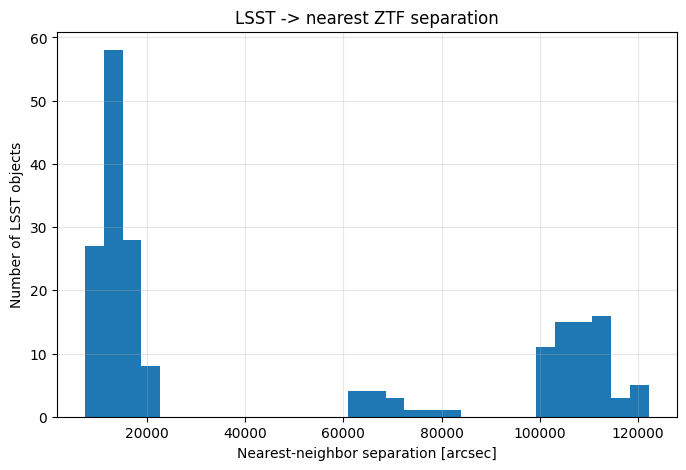

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(nearest["sep_arcsec"], bins=30)
plt.xlabel("Nearest-neighbor separation [arcsec]")
plt.ylabel("Number of LSST objects")
plt.title("LSST -> nearest ZTF separation")
plt.grid(alpha=0.3)
plt.show()

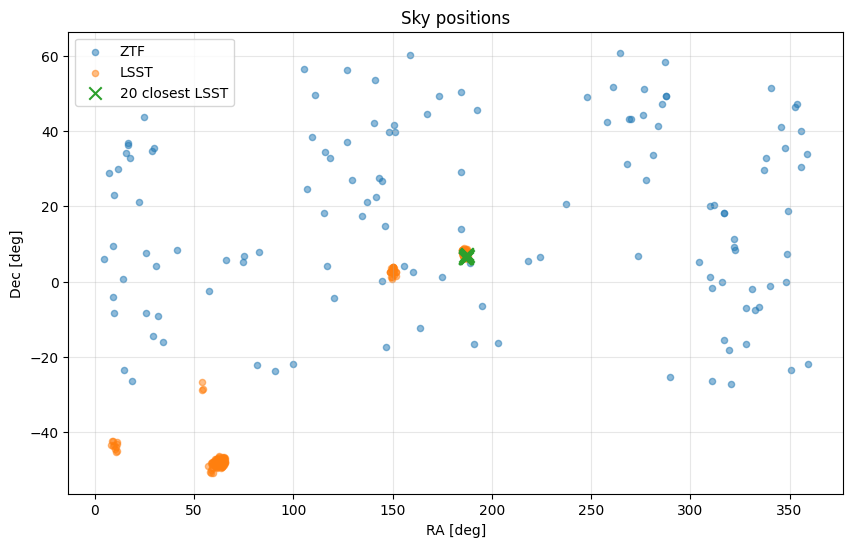

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df_ztf[ztf_ra_col], df_ztf[ztf_dec_col], s=20, alpha=0.5, label="ZTF")
plt.scatter(df_lsst[lsst_ra_col], df_lsst[lsst_dec_col], s=20, alpha=0.5, label="LSST")

best20 = nearest_out.sort_values("sep_arcsec").head(20)
plt.scatter(best20["ra_lsst"], best20["dec_lsst"], s=80, marker="x", label="20 closest LSST")

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Sky positions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()